In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import FuncFormatter

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
# Explode the 'job_skills' into individual rows
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

# Limit to the top 10 skills by highest salary
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

skill_stats

,median_salary,skill_count
job_skills,,
sql,120000.0,384849
python,125000.0,380909
aws,135000.0,145381
azure,125000.0,132527
r,119550.0,130892
tableau,111175.0,127213
excel,92500.0,127018
spark,140000.0,114609
power bi,102000.0,98147


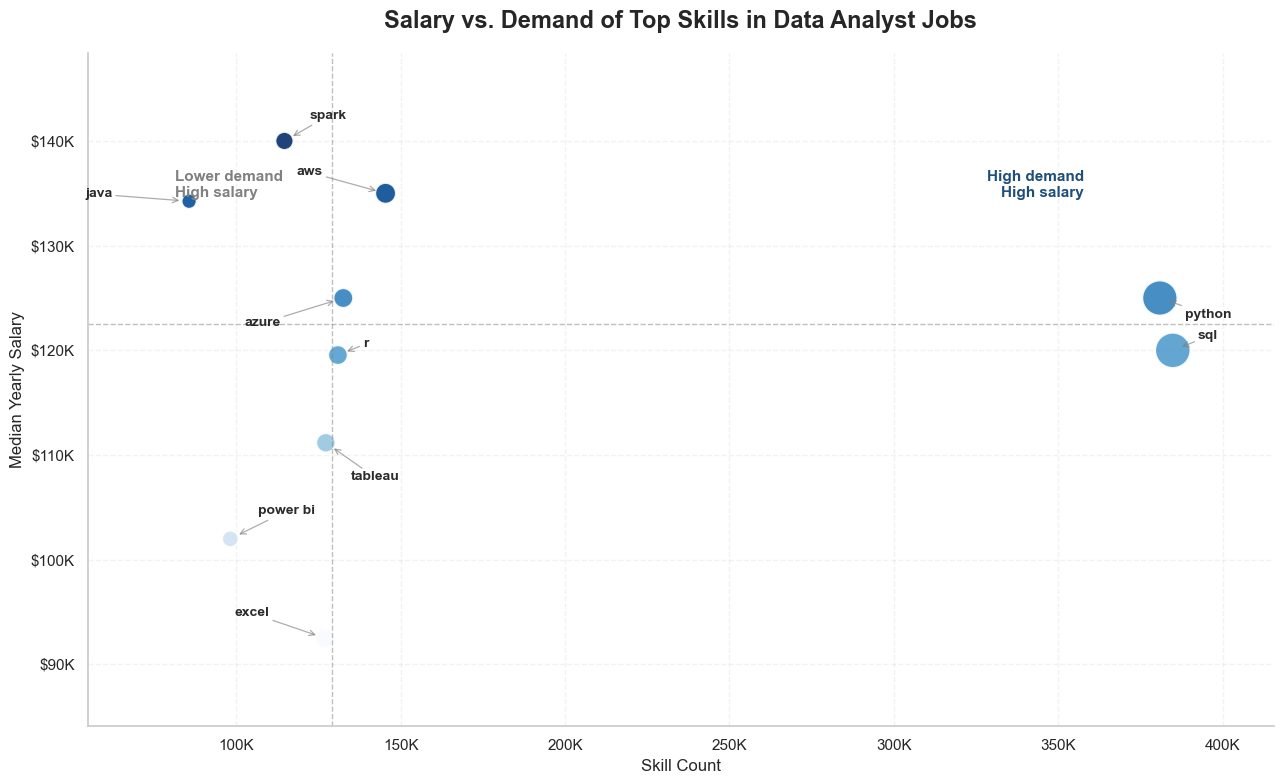

In [9]:


# Prepare data
plot_data = skill_stats.reset_index()
plot_data = plot_data.rename(columns={plot_data.columns[0]: 'skill'})

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(13, 8))

# Reference lines
x_median = plot_data['skill_count'].median()
y_median = plot_data['median_salary'].median()

ax.axvline(x_median, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y_median, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Scatter plot
sns.scatterplot(
    data=plot_data,
    x='skill_count',
    y='median_salary',
    hue='median_salary',
    size='skill_count',
    sizes=(120, 650),
    palette='Blues',
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9,
    legend=False,
    ax=ax
)

# Manual label positions
offsets = {
    'python': (18, -12),
    'sql': (18, 10),
    'aws': (-45, 15),
    'spark': (18, 18),
    'java': (-55, 5),
    'azure': (-45, -18),
    'r': (18, 8),
    'tableau': (18, -25),
    'power bi': (20, 20),
    'excel': (-40, 18)
}

# Add labels with arrows
for _, row in plot_data.iterrows():
    skill = row['skill']
    dx, dy = offsets.get(skill, (15, 15))

    ax.annotate(
        skill,
        xy=(row['skill_count'], row['median_salary']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#2b2b2b',
        ha='left' if dx > 0 else 'right',
        va='center',
        arrowprops=dict(
            arrowstyle='->',
            color='gray',
            lw=0.9,
            alpha=0.65,
            shrinkA=0,
            shrinkB=7
        )
    )

# Quadrant labels
ax.text(
    plot_data['skill_count'].max() * 0.93,
    plot_data['median_salary'].max() * 0.98,
    'High demand\nHigh salary',
    ha='right',
    va='top',
    fontsize=11,
    fontweight='bold',
    color='#1f4e79'
)

ax.text(
    plot_data['skill_count'].min() * 0.95,
    plot_data['median_salary'].max() * 0.98,
    'Lower demand\nHigh salary',
    ha='left',
    va='top',
    fontsize=11,
    fontweight='bold',
    color='gray'
)

# Title and labels
ax.set_title(
    'Salary vs. Demand of Top Skills in Data Analyst Jobs',
    fontsize=17,
    fontweight='bold',
    pad=18
)

ax.set_xlabel('Skill Count', fontsize=12)
ax.set_ylabel('Median Yearly Salary', fontsize=12)

# Axis formatting
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y/1000:.0f}K'))

# Better spacing
x_margin = plot_data['skill_count'].max() * 0.08
y_margin = plot_data['median_salary'].max() * 0.06

ax.set_xlim(
    plot_data['skill_count'].min() - x_margin,
    plot_data['skill_count'].max() + x_margin
)

ax.set_ylim(
    plot_data['median_salary'].min() - y_margin,
    plot_data['median_salary'].max() + y_margin
)

# Clean style
ax.grid(axis='both', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()

plt.savefig(
    "salary_vs_demand_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "salary_vs_demand_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "salary_vs_demand_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "salary_vs_demand_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()